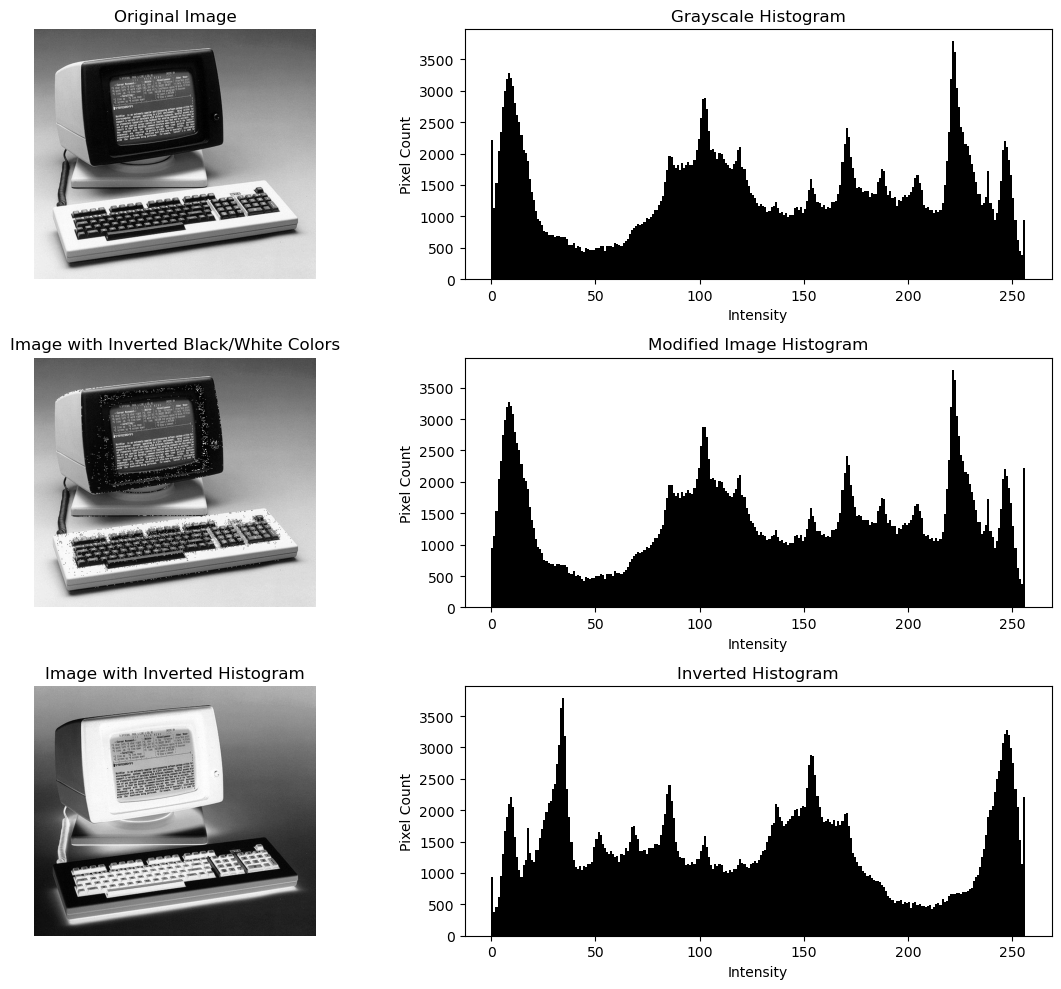

In [4]:
import cv2
import matplotlib.pyplot as plt

def process_image_and_display(image_path):
    """
    تابع اصلی برای پردازش تصویر و نمایش هیستوگرام‌ها
    """
    # خواندن تصویر ورودی
    original_bgr_image = cv2.imread(image_path)
    
    # تبدیل تصویر به فضای رنگی خاکستری و RGB
    grayscale_image = cv2.cvtColor(original_bgr_image, cv2.COLOR_BGR2GRAY)
    rgb_image = cv2.cvtColor(original_bgr_image, cv2.COLOR_BGR2RGB)
    
    # کپی از تصاویر برای پردازش‌های بعدی
    rgb_image_copy = rgb_image.copy()
    grayscale_image_copy = grayscale_image.copy()
    
    # ایجاد figure با سایز مناسب
    plt.figure(figsize=(12, 10))

    # موقعیت (1,1): نمایش تصویر اصلی RGB
    plt.subplot(3, 2, 1)
    plt.imshow(rgb_image)
    plt.title('Original Image')
    plt.axis('off')

    # موقعیت (1,2): نمایش هیستوگرام تصویر خاکستری شده
    plt.subplot(3, 2, 2)
    plt.hist(grayscale_image.ravel(), bins=256, range=(0, 256), color='black')
    plt.title('Grayscale Histogram')
    plt.xlabel('Intensity')
    plt.ylabel('Pixel Count')

    # تبدیل پیکسل‌های سفید به سیاه و سیاه به سفید
    # تشخیص پیکسل‌های سیاه (همه کانال‌ها صفر)
    black_pixels_mask = (rgb_image_copy[:,:,0] == 0) & (rgb_image_copy[:,:,1] == 0) & (rgb_image_copy[:,:,2] == 0)
    # تشخیص پیکسل‌های سفید (همه کانال‌ها 255)
    white_pixels_mask = (rgb_image_copy[:,:,0] == 255) & (rgb_image_copy[:,:,1] == 255) & (rgb_image_copy[:,:,2] == 255)
    # اعمال تغییرات: سیاه‌ها به سفید و سفیدها به سیاه تبدیل می‌شوند
    rgb_image_copy[black_pixels_mask] = [255, 255, 255]
    rgb_image_copy[white_pixels_mask] = [0, 0, 0]
    
    # موقعیت (2,1): نمایش تصویر پس از تبدیل رنگ‌ها
    plt.subplot(3, 2, 3)
    plt.imshow(rgb_image_copy)
    plt.title('Image with Inverted Black/White Colors')
    plt.axis('off')
    
    # تبدیل تصویر تغییر یافته به خاکستری برای هیستوگرام
    modified_grayscale_image = cv2.cvtColor(rgb_image_copy, cv2.COLOR_RGB2GRAY)
    
    # موقعیت (2,2): نمایش هیستوگرام تصویر تغییر یافته
    plt.subplot(3, 2, 4)
    plt.hist(modified_grayscale_image.ravel(), bins=256, range=(0, 256), color='black')
    plt.title('Modified Image Histogram')
    plt.xlabel('Intensity')
    plt.ylabel('Pixel Count')

    # اعمال معکوس‌سازی هیستوگرام (منفی کردن تصویر)
    inverted_grayscale_image = 255 - grayscale_image
    
    # موقعیت (3,1): نمایش تصویر با هیستوگرام معکوس شده
    plt.subplot(3, 2, 5)
    plt.imshow(inverted_grayscale_image, cmap='gray')
    plt.title('Image with Inverted Histogram')
    plt.axis('off')

    # موقعیت (3,2): نمایش هیستوگرام تصویر معکوس شده
    plt.subplot(3, 2, 6)
    plt.hist(inverted_grayscale_image.ravel(), bins=256, range=(0, 256), color='black')
    plt.title('Inverted Histogram')
    plt.xlabel('Intensity')
    plt.ylabel('Pixel Count')
    
    # تنظیم خودکار فواصل بین زیرنمودارها
    plt.tight_layout()
    plt.show()

# فراخوانی تابع با مسیر تصویر مورد نظر
process_image_and_display(r"C:\Users\PISHRORAYANEH\Downloads\cosmos_1252536572.jpeg")